# Filtros sobre Imágenes CNN
## Clasificación de Biomas de Minecraft con Filtros y CNN
## Primavera 2025
## Alumno : **Leonardo Daniel Rosas Rios**

<img src="Logo_de_la_BUAP.svg.png" alt="Logo BUAP" width="400px" height="300px">

## Obtención de datos

El conjunto de datos utilizado en este proyecto fue obtenido del repositorio de GitHub:
🔗 [https://github.com/Exeton/MinecraftBiomesDataset](https://github.com/Exeton/MinecraftBiomesDataset)

Para facilitar la ejecución y pruebas, se redujo el número de imágenes a **14 por carpeta** (una por bioma), lo que permite mantener un entorno de entrenamiento liviano y ágil sin comprometer completamente la variedad visual.

Los biomas utilizados fueron:
- Beach
- Birch Forest
- Dark Forest
- Desert
- Forest
- Ocean
- Swamp


In [20]:
# librerias
import os #
from glob import glob
import numpy as np # arreglos numericos
import matplotlib.pyplot as plt # Graficacion
from PIL import Image #
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import random
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)



In [21]:
# --- Parámetros globales ---
dataset_path = r'C:\Users\leo_m\OneDrive - Benemérita Universidad Autónoma de Puebla\Cursos\Diplomado Ciencia de Datos\M6 Redes neuronales\Proyecto 2\MinecraftBiomesDataset'
extensiones = ['*.png', '*.jpg', '*.jpeg']
img_size = (64, 64)
max_imagenes_demo = 6  # para demo de filtros

In [22]:
# --- Verificación de ruta ---
print("Ruta existe:", os.path.exists(dataset_path))
if os.path.exists(dataset_path):
    print("Biomas encontrados:", os.listdir(dataset_path))
else:
    print("No se encontró la ruta. Verifica que esté bien escrita.")

Ruta existe: True
Biomas encontrados: ['beach', 'birch_forest', 'dark_forest', 'dessert', 'forest', 'ocean', 'swamp']


## Filtros 

In [23]:
# --- Función para cargar rutas e imprimir imágenes de ejemplo con filtros ---
def mostrar_filtros_de_ejemplo():
    image_paths, labels = [], []

    for biome in os.listdir(dataset_path):
        folder = os.path.join(dataset_path, biome)
        if os.path.isdir(folder):
            for ext in extensiones:
                for img_path in glob(os.path.join(folder, ext)):
                    image_paths.append(img_path)
                    labels.append(biome)


In [24]:
    def show_multiple_filters(original, filtered_list, label, filtro_nombres):
        fig, axs = plt.subplots(1, len(filtered_list) + 1, figsize=(15, 5))
        axs[0].imshow(original)
        axs[0].set_title(f"Original - {label}")
        axs[0].axis('off')
        for i, (filt, nombre) in enumerate(zip(filtered_list, filtro_nombres)):
            axs[i+1].imshow(filt)
            axs[i+1].set_title(nombre)
            axs[i+1].axis('off')
        plt.tight_layout()
        plt.show()


Mostrando ejemplos de filtros para las primeras 6 imágenes...



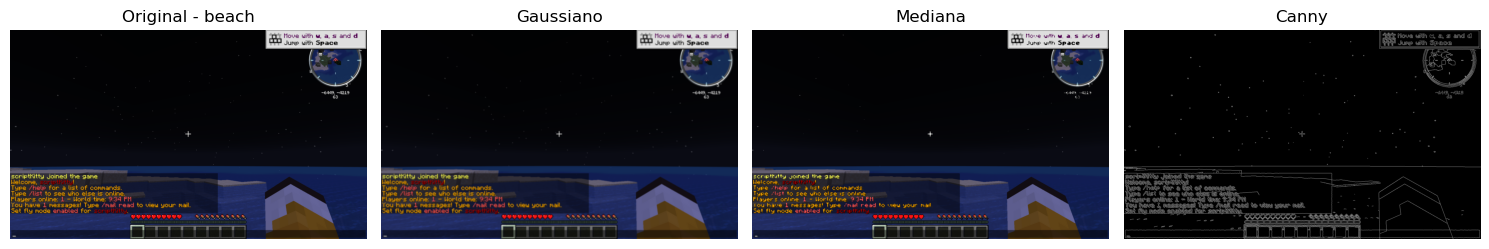

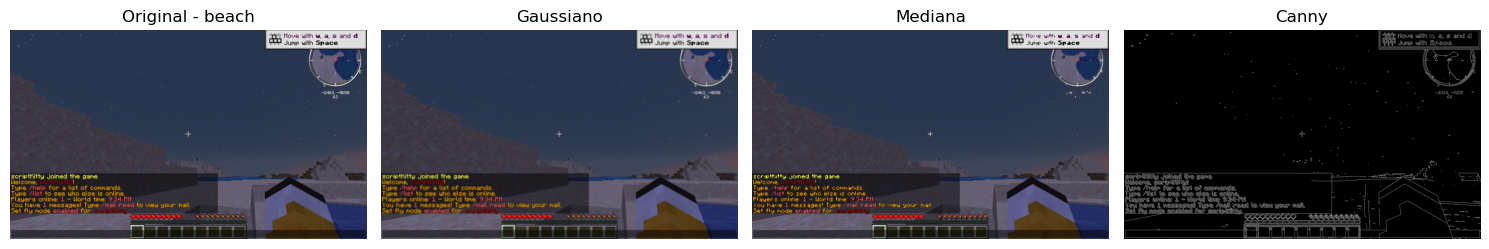

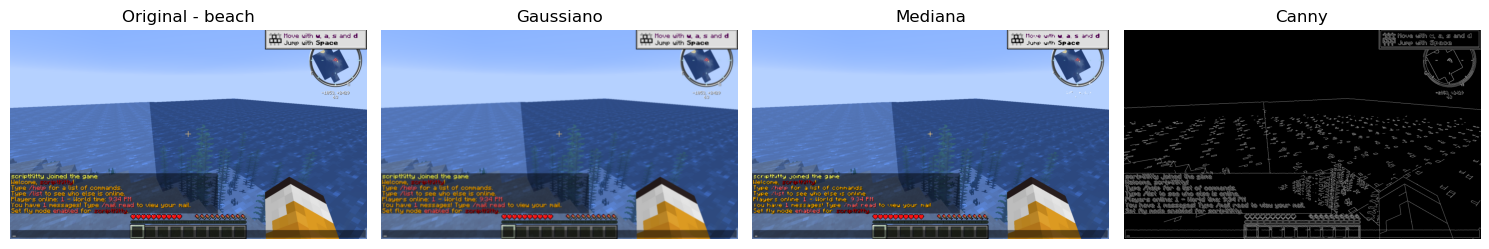

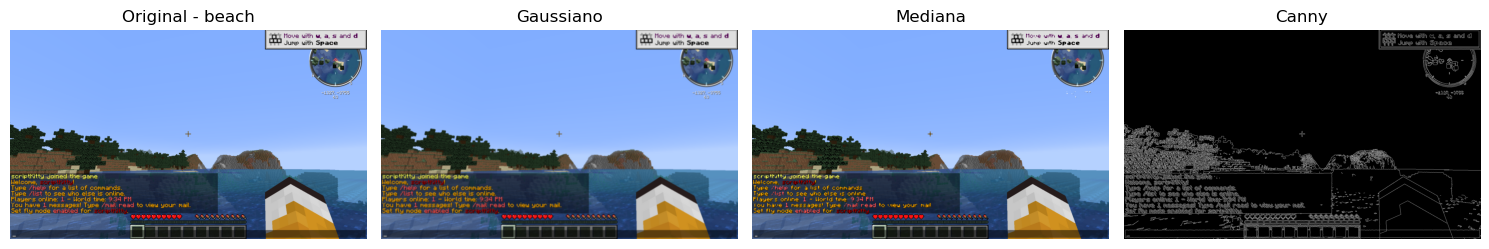

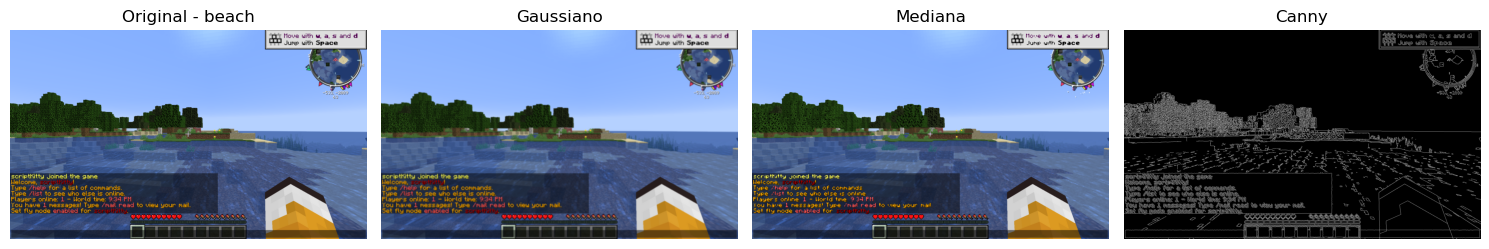

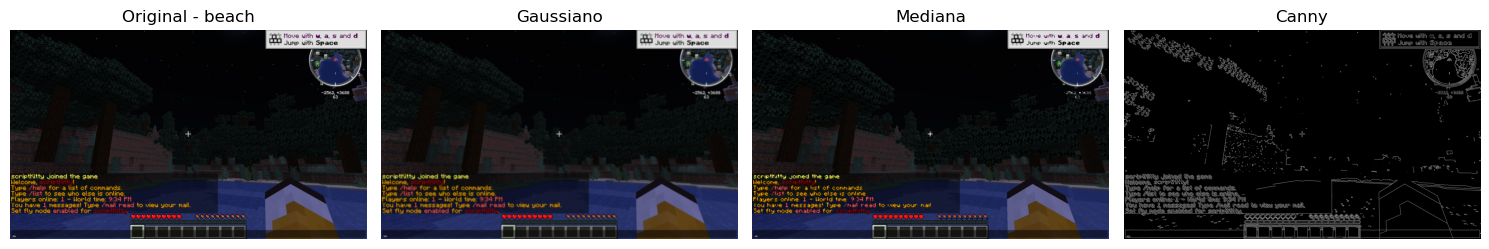

In [25]:
    print(f"Mostrando ejemplos de filtros para las primeras {max_imagenes_demo} imágenes...\n")
    procesadas = 0
    for img_path, label in zip(image_paths, labels):
        try:
            img_pil = Image.open(img_path).convert('RGB')
            img_np = np.array(img_pil)
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

            gauss = cv2.GaussianBlur(img_bgr, (7, 7), 0)
            mediana = cv2.medianBlur(img_bgr, 5)
            canny_rgb = cv2.cvtColor(cv2.Canny(img_bgr, 100, 200), cv2.COLOR_GRAY2RGB)

            filtros_rgb = [
                cv2.cvtColor(gauss, cv2.COLOR_BGR2RGB),
                cv2.cvtColor(mediana, cv2.COLOR_BGR2RGB),
                canny_rgb
            ]

            show_multiple_filters(img_pil, filtros_rgb, label, ["Gaussiano", "Mediana", "Canny"])
            procesadas += 1
            if procesadas >= max_imagenes_demo:
                break
        except Exception as e:
            print(f"Error al procesar {img_path}: {e}")

Se aplicaron los siguientes filtros a las imágenes antes de entrenar el modelo:

1. **Gaussiano**: suaviza la imagen para reducir el ruido.
2. **Mediana**: útil para eliminar el ruido impulsivo sin borrar bordes.
3. **Canny**: detector de bordes, convierte las imágenes en contornos.

Ejemplos visuales de estos filtros fueron generados con las primeras imágenes del dataset, mostrando cómo afecta cada uno la representación visual de los biomas.

In [26]:
# --- Función para cargar imágenes con filtros ---
def cargar_imagenes(filtro='gauss'):
    X, y = [], []
    for biome in os.listdir(dataset_path):
        folder = os.path.join(dataset_path, biome)
        if os.path.isdir(folder):
            for ext in extensiones:
                for img_path in glob(os.path.join(folder, ext)):
                    try:
                        img = Image.open(img_path).convert('RGB').resize(img_size)
                        img_np = np.array(img)
                        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

                        if filtro == 'gauss':
                            filtrada = cv2.GaussianBlur(img_bgr, (7, 7), 0)
                        elif filtro == 'mediana':
                            filtrada = cv2.medianBlur(img_bgr, 5)
                        elif filtro == 'canny':
                            gris = cv2.Canny(img_bgr, 100, 200)
                            filtrada = cv2.cvtColor(gris, cv2.COLOR_GRAY2BGR)
                        else:
                            filtrada = img_bgr

                        img_rgb = cv2.cvtColor(filtrada, cv2.COLOR_BGR2RGB)
                        X.append(img_rgb)
                        y.append(biome)
                    except:
                        continue
    return np.array(X), np.array(y)

## Modelo CNN

- Entrada: 64x64 RGB
- Capas convolucionales: 2 capas con `Conv2D` y `MaxPooling2D`
- Capa oculta: `Dense` de 128 neuronas + `Dropout`
- Salida: capa `softmax` según número de clases

In [27]:
# --- Preprocesamiento y separación ---
def preparar_datos(X, y):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    y_cat = to_categorical(y_encoded)
    X_norm = X / 255.0
    return train_test_split(X_norm, y_cat, test_size=0.2, random_state=42), le


In [28]:
# --- Modelo CNN ---
def crear_modelo(num_clases):
    model = Sequential([
        Input(shape=(64, 64, 3)),
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_clases, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [29]:
# --- Entrenar y evaluar por filtro ---
def entrenar_y_evaluar(X, y, nombre_filtro):
    (X_train, X_test, y_train, y_test), le = preparar_datos(X, y)
    model = crear_modelo(num_clases=y_train.shape[1])
    print(f"\nEntrenando modelo con filtro: {nombre_filtro}")
    model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.2, verbose=1)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Precisión con filtro {nombre_filtro}: {acc*100:.2f}%")
    return model, acc, (X_train, X_test, y_train, y_test)

In [30]:
# --- Probar distintos filtros ---
mostrar_filtros_de_ejemplo()

resultados = {}
for filtro in ['gauss', 'mediana', 'canny']:
    X, y = cargar_imagenes(filtro)
    modelo, acc, _ = entrenar_y_evaluar(X, y, filtro.capitalize())
    resultados[filtro] = acc

# --- Mostrar resumen ---
print("\nResumen de precisión por filtro:")
for k, v in resultados.items():
    print(f"{k.capitalize()}: {v*100:.2f}%")



Entrenando modelo con filtro: Gauss
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.1771 - loss: 1.9306 - val_accuracy: 0.1176 - val_loss: 1.8903
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1615 - loss: 1.9593 - val_accuracy: 0.1765 - val_loss: 1.8574
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2880 - loss: 1.7917 - val_accuracy: 0.2941 - val_loss: 1.8333
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4460 - loss: 1.7169 - val_accuracy: 0.3529 - val_loss: 1.8121
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4345 - loss: 1.5769 - val_accuracy: 0.2941 - val_loss: 1.8150
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5269 - loss: 1.4017 - val_accuracy: 0.2941 - val_loss: 1.6226
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5498 - loss: 1.3220 - val_accuracy: 0.4118 - val_loss: 1.5235
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5769 - loss: 1.2405 - va

## Resultados por Filtro

Cada filtro fue evaluado entrenando la misma arquitectura por 15 épocas. Los resultados obtenidos fueron los siguientes:

| Filtro   | Precisión Final |
|----------|------------------|
| Gauss    | 57.14%           |
| Mediana  | **61.90%**       |
| Canny    | 33.33%           |


Como se observa, el filtro **mediana** ofreció el mejor rendimiento, balanceando eliminación de ruido con preservación de bordes.

In [31]:
# --- Entrenamiento final con data augmentation (Mediana) ---
X_mediana, y_mediana = cargar_imagenes('mediana')
(X_train, X_test, y_train, y_test), le = preparar_datos(X_mediana, y_mediana)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

modelo_final = crear_modelo(num_clases=y_train.shape[1])
history = modelo_final.fit(datagen.flow(X_train, y_train, batch_size=32),
                           epochs=30,
                           validation_data=(X_test, y_test))

# Guardar modelo
modelo_final.save("modelo_minecraft_mediana.h5")
print("Modelo guardado como modelo_minecraft_mediana.h5")

Epoch 1/30


C:\Users\leo_m\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.1597 - loss: 2.0667 - val_accuracy: 0.2857 - val_loss: 1.9163
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2416 - loss: 1.9289 - val_accuracy: 0.3333 - val_loss: 1.7859
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3111 - loss: 1.7332 - val_accuracy: 0.3810 - val_loss: 1.6932
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3703 - loss: 1.6155 - val_accuracy: 0.2857 - val_loss: 1.6125
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3780 - loss: 1.4783 - val_accuracy: 0.3810 - val_loss: 1.5145
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3941 - loss: 1.4840 - val_accuracy: 0.4286 - val_loss: 1.4310
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4782 - loss: 1.3512 - val_accuracy: 0.4286 - val_loss: 1.3657
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4810 - loss: 1.3321 - val_accuracy: 0.3333 - val_loss: 1.3425
Epoch 9/30

Modelo guardado como modelo_minecraft_mediana.h5


## Mejora con Aumento de Datos

Se utilizó `ImageDataGenerator` para aplicar técnicas de aumento como:
- Rotación aleatoria
- Zoom
- Desplazamiento horizontal y vertical
- Inversión horizontal

Esto se aplicó únicamente al conjunto con filtro **mediana**, por ser el más prometedor.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5714 - loss: 1.2160

Pérdida final en test: 1.2160
Precisión final en test: 57.14%


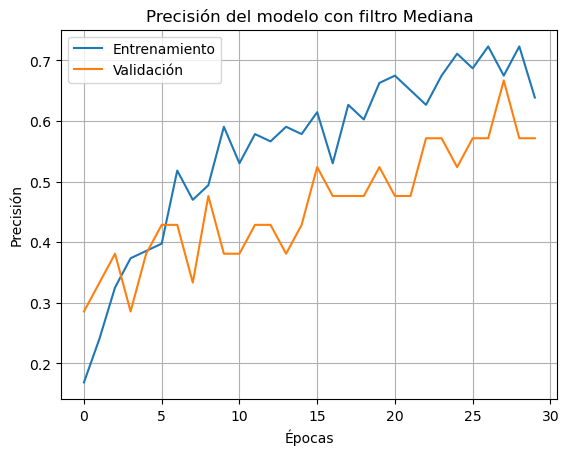

In [32]:
# Evaluación final
loss, acc = modelo_final.evaluate(X_test, y_test)
print(f"\nPérdida final en test: {loss:.4f}")
print(f"Precisión final en test: {acc*100:.2f}%")

# Gráfica de desempeño
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo con filtro Mediana')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()

###  Resultados finales

- **Precisión en test**: 57.14%
- **Pérdida final**: 1.2160

##  Conclusión

- El filtro mediana fue el más efectivo para este problema.
- El filtro Canny no es recomendable para esta tarea, ya que convierte las imágenes en contornos que dificultan la extracción de características visuales complejas por parte de la CNN.
- La reducción del tamaño del dataset fue esencial para un entrenamiento ágil, pero limitar el número de imágenes también afecta el rendimiento general.
- El aumento de datos permitió mejorar ligeramente la generalización del modelo, aunque aún se observan limitaciones por el tamaño del dataset.
- Como trabajo futuro, se recomienda expandir el número de imágenes y explorar arquitecturas más profundas o preentrenadas.
